In [1]:
#Use cropscape, yvonne allen's gcpo lcc flood frequency dataset, wmu, and wrep to calculate available energy.

In [2]:
import rasterio
import geopandas as gpd
from rasterio.mask import mask
import numpy as np
from rasterio.plot import show
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from shapely.geometry import box, shape
import duckdb
import pandas as pd
from shapely.ops import unary_union
# 1 corn, 3 rice, 4 sorghum, 5 soybeans, 29 millet, 63 forest, 83 water, 87 wetlands, 92 aquaculture,
#111 open water, 141 deciduous forest, 190 woody wetlands, 195 herbaceous wetlands
habitats = {1:'Corn', 3:'Rice', 4:'Sorghum', 5:'Soybeans', 29:'Millet', 83:'OpenWater', 87:'EmergentWetlands', 92:'Aquaculture', 111:'OpenWater',190: 'WoodyWetlands', 195:'EmergentWetlands'}



In [3]:
###############################################
#
#
# Read flooded crops by merging cropscape and GCPO LCC Flood > 20 
#
#
###############################################

In [4]:
'''Read in NLCD, mask with aoi.  Mask out all but urban classes and set urban values to 1.'''
cogin = 'D:\gis\BaseData\cdl_2024_30m.tif'
cog = rasterio.open(cogin)

# Azure Blob Storage URL
url = "abfs://publicparquet/LMVJV_Boundary.parquet"
# Storage account credentials
storage_options = {
    "account_name": "giscog"
}
# Read the Parquet file directly into a GeoDataFrame
gdf = gpd.read_parquet(url, storage_options=storage_options)
gdf = gdf.to_crs(cog.crs)
gdf['geometry'] = gdf.buffer(50000)

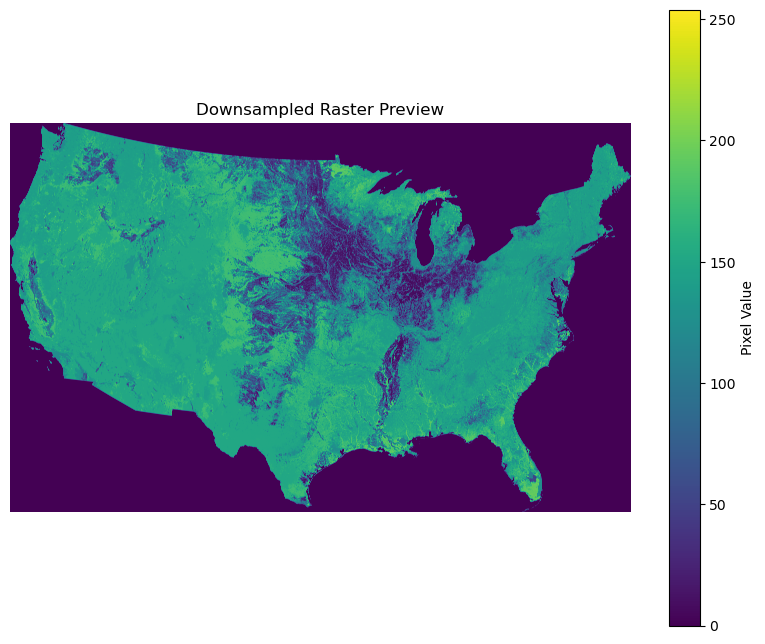

In [5]:
# Define a downsampling factor (adjust as needed)
downsample_factor = 10

# Calculate the shape of the downsampled image
out_shape = (
    cog.count,
    cog.height // downsample_factor,
    cog.width // downsample_factor
)

# Read the first band with downsampling
data = cog.read(
    1,
    out_shape=out_shape,
    resampling=Resampling.nearest
)

# Plot the downsampled raster
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')
plt.title("Downsampled Raster Preview")
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

(32213, 25835)
Unique values in crop:
[  0   1   2   3   4   5   6  10  11  12  13  14  21  23  24  26  27  28
  29  31  34  36  37  42  43  44  45  46  47  48  49  50  53  54  57  58
  59  60  61  67  68  69  70  71  72  74  76  77  92 111 121 122 123 124
 131 141 142 143 152 176 190 195 205 209 211 212 216 218 219 220 221 222
 225 226 228 229 236 238 240 241 242 243 254]


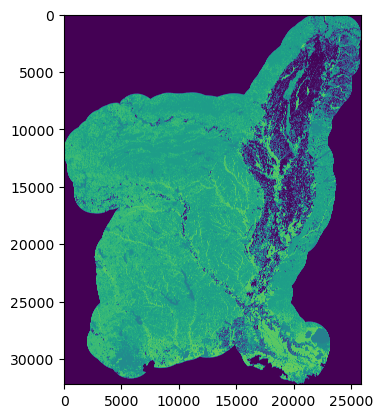

<Axes: >

In [6]:
crop, crop_transform =rasterio.mask.mask(cog, gdf.dissolve().geometry, crop=True)
crop = crop[0]
print(crop.shape)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)
show(crop)

In [7]:
target_classes = [1, 3, 4, 5, 29, 63, 83, 87, 92, 111, 141, 190, 195]
# 1 corn, 3 rice, 4 sorghum, 5 soybeans, 29 millet, 63 forest, 83 water, 87 wetlands, 92 aquaculture, 111 open water, 141 deciduous forest, 190 woody wetlands, 195 herbaceous wetlands
binary_mask = np.isin(crop, target_classes).astype(np.uint8)
binary_mask = binary_mask
crop = np.where(binary_mask, crop, np.nan)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)

Unique values in crop:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]


EPSG:5070


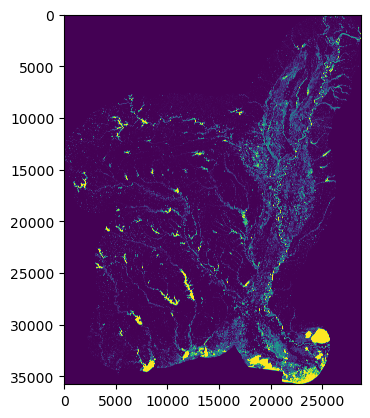

<Axes: >

In [8]:
'''Read in NLCD, mask with aoi.  Mask out all but urban classes and set urban values to 1.'''
floodin = 'https://giscog.blob.core.windows.net/publiccogs/GCPO_IF_albers.tif'
floodread = rasterio.open(floodin)
print(floodread.crs)
flood, flood_transform =rasterio.mask.mask(floodread, gdf.dissolve().geometry, crop=True)
show(flood)

In [9]:
from rasterio.warp import reproject, Resampling

# Prepare an empty array to hold the resampled flood data
resampled_flood = np.empty_like(crop, dtype=flood.dtype)

# Reproject and resample flood to match crop
reproject(
    source=flood,
    destination=resampled_flood,
    src_transform=flood_transform,
    src_crs=floodread.crs,
    dst_transform=crop_transform,
    dst_crs=cog.crs,
    resampling=Resampling.nearest
)

# Create mask and extract crop values
flood_mask = resampled_flood >= 20
print('80', np.count_nonzero(flood_mask))
print('50', np.count_nonzero(resampled_flood >= 50))
print('20', np.count_nonzero(resampled_flood >= 20))
print('lt20', np.count_nonzero(resampled_flood < 20))
notflood_mask = resampled_flood < 20
flooded_crop_values = crop[flood_mask]

# Create a new array filled with NaNs
flooded_crop_2d = np.full(crop.shape, np.nan, dtype=np.float32)
notflooded_crop = np.full(crop.shape, np.nan, dtype=np.float32)
# Fill in the crop values where flood condition is met
flooded_crop_2d[flood_mask] = crop[flood_mask]
notflooded_crop[notflood_mask] = crop[notflood_mask]

80 60484929
50 34514660
20 60484929
lt20 771737926


In [10]:
print('crop', np.count_nonzero(crop >0))
print('notflooded crop', np.count_nonzero(notflooded_crop >0))
print('flooded crop', np.count_nonzero(flooded_crop_2d > 0))
print('')
print('notflooded crop %', np.count_nonzero(notflooded_crop >0)/np.count_nonzero(crop >0))
print('flooded crop %', np.count_nonzero(flooded_crop_2d > 0)/np.count_nonzero(crop >0))

crop 238902832
notflooded crop 186758503
flooded crop 52144329

notflooded crop % 0.7817341529044746
flooded crop % 0.21826584709552543


In [11]:
print(crop.shape)
unique_values = np.unique(crop[~np.isnan(crop)])
print("Unique values in crop:")
print(unique_values)
print(resampled_flood.shape)
#show(flooded_crop_2d)

(32213, 25835)
Unique values in crop:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]
(32213, 25835)


In [12]:

unique_values = np.unique(flooded_crop_2d[~np.isnan(flooded_crop_2d)])

print("Unique values in flooded_crop_2d:")
print(unique_values)


Unique values in flooded_crop_2d:
[  1.   3.   4.   5.  29.  92. 111. 141. 190. 195.]


crop count 52144329


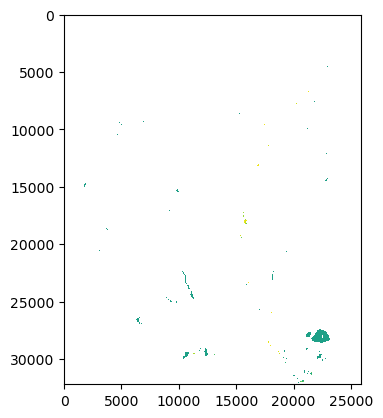

<Axes: >

In [13]:
print('crop count', np.count_nonzero(flooded_crop_2d >= 1))
show(flooded_crop_2d)

In [14]:
shapes = rasterio.features.shapes(flooded_crop_2d, transform=crop_transform)

# Separate geometries and values
geometries = []
values = []

for geom, value in shapes:
    geometries.append(shape(geom))
    values.append(value)

# Create GeoDataFrame with both geometry and raster value
gdf_vector = gpd.GeoDataFrame({'geometry': geometries, 'raster_value': values})
gdf_vector = gdf_vector.set_geometry('geometry')
gdf_vector = gdf_vector.set_crs(5070)

#gdf_vector = gdf_vector.to_wkt().geometry
gdf_vector.head()

,geometry,raster_value
0,"POLYGON ((567165 1649805, 567165 1649715, 5672...",5.0
1,"POLYGON ((569625 1649745, 569625 1649685, 5696...",5.0
2,"POLYGON ((565425 1649715, 565425 1649685, 5654...",5.0
3,"POLYGON ((565455 1649715, 565455 1649685, 5654...",190.0
4,"POLYGON ((565485 1649715, 565485 1649685, 5655...",5.0


In [15]:
gdf_vector['Class'] = gdf_vector['raster_value'].map(habitats)
floodedcrops = gdf_vector

In [16]:
###############################################
#
#
# Read WRP from PADUS
#
#
###############################################

In [17]:
print(gdf)
gdf = gdf.to_wkb()
#gdf_vector['geometry'] = gdf_vector.to_wkt().geometry
'''
Read in PADUS
'''
con = duckdb.connect()
con.install_extension("spatial")
con.load_extension("spatial")
con.install_extension("azure")
con.load_extension("azure")

con.sql('''CREATE OR REPLACE TABLE jvaoi AS SELECT * EXCLUDE geometry, ST_Geomfromwkb(geometry) AS geometry from gdf''')

   OBJECTID  AREA            PERIMETER                 ACRES  \
0         1  None  2877110.85099999979  25444979.37900000438   

               HECTARES         BufferDist    SqKM BCR_NAME  \
0  10297217.82200000063  10000.00000000000  102972     None   

            Shape_Leng Shape_Area  \
0  4044245.38767000008       None   

                                            geometry  
0  POLYGON ((-109300.849 1289487.953, -109548.39 ...  


In [18]:
#con.sql("""
#CREATE OR REPLACE TABLE prot AS 
#SELECT Unit_Nm, geometry FROM read_parquet('D:\\gis\\BaseData\\padus_fee_easement.parquet')
#WHERE Unit_Nm LIKE '%WRP%' OR Unit_Nm LIKE '%WREP%'
#""")

con.sql("""
CREATE OR REPLACE TABLE prot AS 
SELECT Program, geometry FROM read_parquet('D:\\source\\waterfowl\\waterfowlenergynotebook\\stewardshipLandEasements_2_2025.parquet')
WHERE Program LIKE '%WRP%' OR PROGRAM LIKE '%WRE%'
""")

In [19]:
con.sql("""
CREATE OR REPLACE TABLE wrp AS 
SELECT Program, ST_Intersection(jvaoi.geometry, st_buffer(prot.geometry,0)) as geometry
FROM prot
JOIN jvaoi ON 
ST_Intersects(jvaoi.geometry, st_buffer(prot.geometry,0))
""")

In [20]:
from shapely import wkt, wkb
# Need huc12 geometry
wrpdf = con.sql('SELECT ST_AsText(geometry) as geometry from wrp').df()
wrpdf['geometry'] = wrpdf['geometry'].apply(wkt.loads)
wrpdf = gpd.GeoDataFrame(wrpdf, geometry='geometry', crs=5070)

In [21]:
wrpdf.head()

,geometry
0,"POLYGON ((-9738.187 1238212.337, -9722.181 123..."
1,"POLYGON ((-19900.882 1198137.142, -20203.125 1..."
2,"POLYGON ((139374.807 1179709.756, 139374.929 1..."
3,"MULTIPOLYGON (((115291.379 1191094.823, 115279..."
4,"POLYGON ((136812.307 1182890.126, 136816.455 1..."


In [22]:
###############################################
#
#
# Read WMU from parquet
#
#
###############################################

In [23]:
# Azure Blob Storage URL
wmuurl = "abfs://publicparquet/wmu_8_2025.parquet"
storage_options = {
    "account_name": "giscog"
}
# Read the Parquet file directly into a GeoDataFrame
wmu = gpd.read_parquet(wmuurl, storage_options=storage_options)
wmu = wmu.sort_values("last_edi_1", ascending=False)
print(wmu.columns)

Index(['HabitatTyp', 'last_edite', 'last_edi_1', 'OakPCT', 'HrvstPCT', 'Acre',
       'DED', 'Functional', 'MSProd', 'Reviewed', 'geometry'],
      dtype='object')


In [24]:
# list to collect geometries we keep
keep = []

for idx, row in wmu.iterrows():
    geom = row.geometry
    # check if this geom intersects anything already kept
    intersects = False
    for g in keep:
        if geom.intersects(g):
            intersects = True
            break
    if not intersects:
        keep.append(geom)

# subset the GeoDataFrame to the kept geometries
wmu_no_overlaps = wmu[wmu.geometry.isin(keep)]
print(wmu.shape, "→", wmu_no_overlaps.shape)
print((wmu.area*0.000247105).sum(), "→", (wmu_no_overlaps.area*0.000247105).sum())
wmu = wmu_no_overlaps

(4085, 11) → (3537, 11)
406919.4672148549 → 315282.47298178775


In [25]:
wmu.columns

Index(['HabitatTyp', 'last_edite', 'last_edi_1', 'OakPCT', 'HrvstPCT', 'Acre',
       'DED', 'Functional', 'MSProd', 'Reviewed', 'geometry'],
      dtype='object')

In [26]:
print(wmu['HabitatTyp'].unique())
wmu.loc[wmu.HabitatTyp=='Woody Wetland', ['HabitatTyp']] = 'woodywetlands'
wmu.loc[wmu.HabitatTyp=='Open Water', ['HabitatTyp']] = 'openwater'
wmu.loc[wmu.HabitatTyp=='Herbaceous Wetlands', ['HabitatTyp']] = 'emergentwetlands'
wmu.loc[wmu.HabitatTyp=='Open-aquatic', ['HabitatTyp']] = 'aquaculture'
wmu.loc[wmu.HabitatTyp=='Open-Aquatic', ['HabitatTyp']] = 'aquaculture'
wmu.loc[wmu.HabitatTyp=='Moist-Soil', ['HabitatTyp']] = 'moistsoil'
wmu.loc[wmu.HabitatTyp=='Reforested hardwoods', ['HabitatTyp']] = 'hardwoods'
wmu.loc[wmu.HabitatTyp=='Hardwoods', ['HabitatTyp']] = 'hardwoods'
wmu.loc[wmu.HabitatTyp=='Forested swamp', ['HabitatTyp']] = 'woodywetlands'
wmu['HabitatTyp'] = wmu['HabitatTyp'].str.lower()
print(wmu['HabitatTyp'].unique())

['Moist-Soil' 'Hardwoods' 'Forested swamp' 'Reforested hardwoods'
 'Shrub swamp' 'Rice' 'Open-Aquatic' 'Corn' 'Soybeans' 'WRP'
 'Woody Wetland' 'Millet' 'Open-aquatic' 'Mudflat' 'Milo' 'Fallow' 'Other'
 'Cropland']
['moistsoil' 'hardwoods' 'woodywetlands' 'shrub swamp' 'rice'
 'aquaculture' 'corn' 'soybeans' 'wrp' 'millet' 'mudflat' 'milo' 'fallow'
 'other' 'cropland']


In [27]:
print('floodedcrops', (floodedcrops.area*0.000247105).sum())
from shapely.ops import unary_union

# Fix geometries and combine WMU polygons into one MultiPolygon
wmu_union = unary_union(wmu.buffer(0))  # buffer(0) cleans up invalid geometries

# Ensure CRS match
assert floodedcrops.crs == wmu.crs

# Compute difference
floodedcrops["geometry"] = floodedcrops.geometry.apply(lambda g: g.difference(wmu_union))

# Optionally drop empty geometries
floodedcrops = floodedcrops[~floodedcrops.is_empty]
print('floodedcrops', (floodedcrops.area*0.000247105).sum())

floodedcrops 185081785.7262975
floodedcrops 184872720.72114182


In [28]:
print('wrpdf', (wrpdf.area*0.000247105).sum())
from shapely.ops import unary_union

# Ensure CRS match
assert wrpdf.crs == wmu.crs

# Compute difference
wrpdf["geometry"] = wrpdf.geometry.apply(lambda g: g.difference(wmu_union))

# Optionally drop empty geometries
wrpdf = wrpdf[~wrpdf.is_empty]
print('wrpdf', (wrpdf.area*0.000247105).sum())

wrpdf 954199.0872470771
wrpdf 943530.9643725872


In [29]:
print('floodedcrops', (floodedcrops.area*0.000247105).sum())
from shapely.ops import unary_union

# Fix geometries and combine WMU polygons into one MultiPolygon
wrpdf_union = unary_union(wrpdf.buffer(0))  # buffer(0) cleans up invalid geometries

# Ensure CRS match
assert floodedcrops.crs == wrpdf.crs

# Compute difference
floodedcrops["geometry"] = floodedcrops.geometry.apply(lambda g: g.difference(wrpdf_union))

# Optionally drop empty geometries
floodedcrops = floodedcrops[~floodedcrops.is_empty]
print('floodedcrops', (floodedcrops.area*0.000247105).sum())

floodedcrops 184872720.72114182


D:\mambaforge\envs\newduckdb\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


floodedcrops 183929280.7701515


In [30]:
wmu = wmu.rename(columns={'HabitatTyp': 'Class'})
wmu['source'] = 'wmu'
wrpdf['source'] = 'wrp'
floodedcrops['source'] = 'floodedcropscape'
print('wmu', (wmu.area*0.000247105).sum())
print('wrpdf', (wrpdf.area*0.000247105).sum())
print('floodedcrops', (floodedcrops.area*0.000247105).sum())
wrpdf['Class'] = 'wrp'
merged_gdf = pd.concat([wmu, wrpdf], ignore_index=True)
merged_gdf = pd.concat([merged_gdf, floodedcrops], ignore_index=True)
merged_gdf = gpd.GeoDataFrame(merged_gdf, geometry='geometry', crs=wmu.crs)
print('====================')
print('merged_gdf', (merged_gdf.area*0.000247105).sum())

wmu 315282.47298178775
wrpdf 943530.9643725872
floodedcrops 183929280.7701515
merged_gdf 185188094.20750585


In [31]:
merged_gdf['acres'] = merged_gdf.area * 0.000247105
merged_gdf = merged_gdf.dropna(subset=['Class'])
merged_gdf = merged_gdf.drop(columns=['raster_value'])
print(merged_gdf['acres'].sum())
merged_gdf.head()

12134581.922925558


,Class,last_edite,last_edi_1,OakPCT,HrvstPCT,Acre,DED,Functional,MSProd,Reviewed,geometry,source,acres
0,moistsoil,blaine_elliott@fws.gov,2025-08-15,0.0,0.0,0E-11,0E-11,Yes,Low,Yes,"MULTIPOLYGON (((369843.516 1026258.849, 369860...",wmu,74.836769
1,hardwoods,blaine_elliott@fws.gov,2025-08-15,29.0,0.0,0E-11,0E-11,Yes,NA,Yes,"MULTIPOLYGON (((430681.601 1371584.174, 430685...",wmu,15.319181
2,woodywetlands,blaine_elliott@fws.gov,2025-08-15,29.0,0.0,0E-11,0E-11,Yes,NA,Yes,"MULTIPOLYGON (((397072.419 1360962.904, 397081...",wmu,320.904454
3,hardwoods,blaine_elliott@fws.gov,2025-08-15,70.0,0.0,0E-11,0E-11,Yes,NA,Yes,"MULTIPOLYGON (((398899.286 1368028.521, 399020...",wmu,37.296980
4,moistsoil,blaine_elliott@fws.gov,2025-08-15,0.0,0.0,0E-11,0E-11,Yes,Low,Yes,"MULTIPOLYGON (((401473.013 1360406.61, 401483....",wmu,17.984499


In [32]:
len(merged_gdf)

2198582

In [33]:
print('count',len(merged_gdf))
print('area sum',(merged_gdf.area*0.000247105).sum())
print('acres sum',merged_gdf['acres'].sum())

count 2198582
area sum 12134581.922925558
acres sum 12134581.922925558


In [34]:
merged_gdf.to_parquet('energy_9_2025.parquet')